In [29]:
import pandas as pd
# Load retracted papers metadata
retracted_papers = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retraction_watch.csv")

# Load country publication data
country_publications = pd.read_csv(r"C:\Users\Parsa\Downloads\scimagojr country rank 1996-2023 (1).csv")

# Define search terms
search_terms = ['computer science', 'data science', 'engineering -electrical']

# Filter retracted papers by subject
def filter_retracted_papers(df, search_terms):
    return df[df['Subject'].str.contains('|'.join(search_terms), case=False, na=False)]

filtered_retracted = filter_retracted_papers(retracted_papers, search_terms)

# Expand multiple-country entries
filtered_retracted['Country'] = filtered_retracted['Country'].str.split(';')
filtered_retracted = filtered_retracted.explode('Country')
filtered_retracted['Country'] = filtered_retracted['Country'].str.strip()

# Count retracted papers per country
retracted_counts = filtered_retracted['Country'].value_counts().rename_axis('Country').reset_index(name='Retracted_Count')

C:\Users\Parsa\AppData\Local\Temp\ipykernel_28388\74760230.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_retracted['Country'] = filtered_retracted['Country'].str.split(';')


In [3]:
retracted_counts

,Country,Retracted_Count
0,China,6817
1,India,1405
2,Saudi Arabia,352
3,United States,253
4,South Korea,211
...,...,...
108,Liberia,1
109,Armenia,1
110,Maldives,1
111,Eritrea,1


In [30]:
# Rename 'Document' column to match easier reference
country_publications.rename(columns={'Documents': 'Total_Publications'}, inplace=True)

# Merge with country publication data
merged_data = retracted_counts.merge(country_publications[['Country', 'Total_Publications']], on='Country', how='left')

# Calculate retraction rate
merged_data['Retraction_Rate'] = (merged_data['Retracted_Count'] / merged_data['Total_Publications'])

# Save results
merged_data.to_csv('retraction_rate_by_country.csv', index=False)

merged_data.head()

,Country,Retracted_Count,Total_Publications,Retraction_Rate
0,China,6817,10372322.0,0.000657
1,India,1405,2970196.0,0.000473
2,Saudi Arabia,352,419090.0,0.000840
3,United States,253,16047770.0,0.000016
4,South Korea,211,1604519.0,0.000132


In [5]:
merged_data[merged_data['Country']=="Iran"]

,Country,Retracted_Count,Total_Publications,Retraction_Rate
6,Iran,169,886359.0,0.000191


C:\Users\Parsa\AppData\Local\Temp\ipykernel_28388\2719552560.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=sorted_data, x="Country", y="Retraction_Rate", palette="coolwarm")


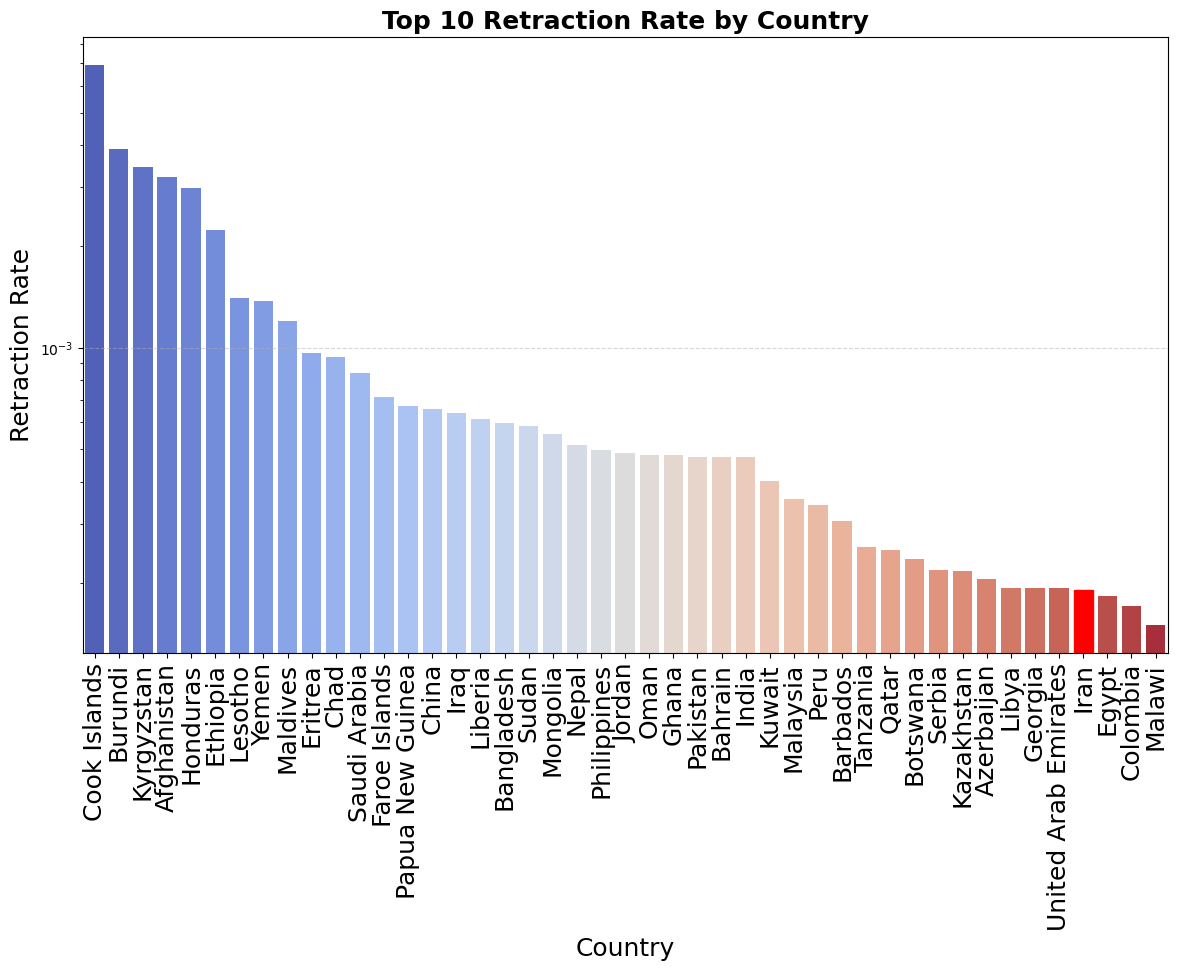

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data by retraction rate
sorted_data = merged_data.sort_values(by="Retraction_Rate", ascending=False)[:45]

# Increase figure size
plt.figure(figsize=(14, 8))

# Create the barplot
bars = sns.barplot(data=sorted_data, x="Country", y="Retraction_Rate", palette="coolwarm")

# Highlight Iran
for bar, country in zip(bars.patches, sorted_data["Country"]):
    if country == "Iran":
        bar.set_color("red")  # Change color for Iran

# Rotate x-axis labels for readability
plt.xticks(rotation=90, fontsize=18)
plt.xlabel("Country", fontsize=18)
plt.ylabel("Retraction Rate", fontsize=18)
plt.title("Top 10 Retraction Rate by Country", fontsize=18, fontweight="bold")

# Use log scale to handle large differences
plt.yscale("log")

# Grid for better visualization
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Show the plot
plt.show()

C:\Users\Parsa\AppData\Local\Temp\ipykernel_28388\4203097214.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=sorted_data, x="Country", y="Retraction_Rate", palette="coolwarm")
C:\Users\Parsa\AppData\Local\Temp\ipykernel_28388\4203097214.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bars.set_xticklabels(x_labels, rotation=90, fontsize=10)


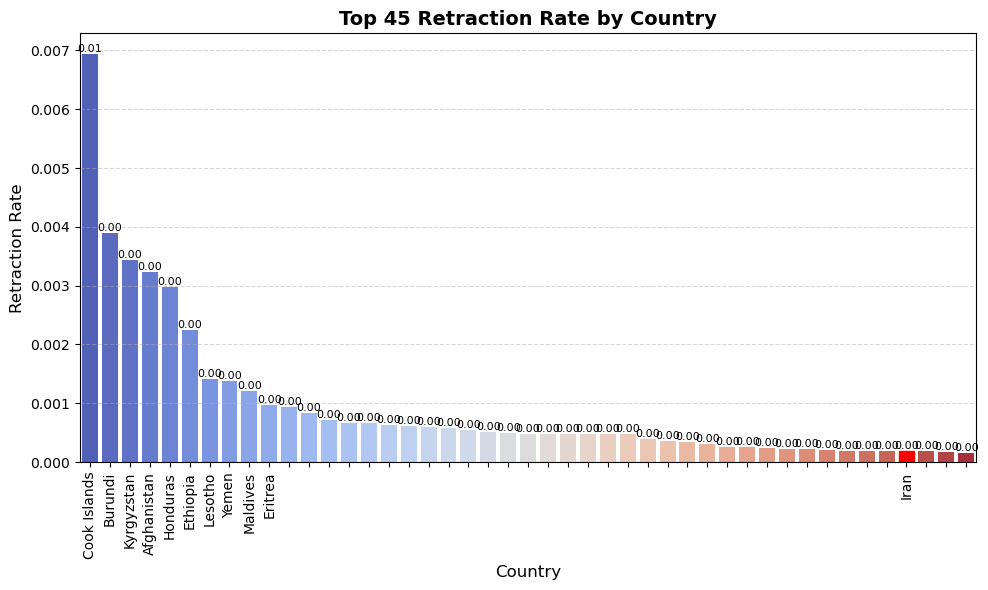

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data by retraction rate
sorted_data = merged_data.sort_values(by="Retraction_Rate", ascending=False)[:45]

# Adjust the figure size
plt.figure(figsize=(10, 6))  # Smaller figure for a 2-column layout

# Create the barplot
bars = sns.barplot(data=sorted_data, x="Country", y="Retraction_Rate", palette="coolwarm")

# Highlight Iran
for bar, country in zip(bars.patches, sorted_data["Country"]):
    if country == "Iran":
        bar.set_color("red")  # Highlight Iran in red

# Add data labels on top of bars
for bar in bars.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}", 
             ha='center', va='bottom', fontsize=8)

# Update x-axis labels to show only top 10 countries and Iran
visible_labels = list(sorted_data["Country"][:10])  # Top 10 countries
if "Iran" in sorted_data["Country"].values and "Iran" not in visible_labels:
    visible_labels.append("Iran")  # Add Iran if not already in the top 10

# Replace other x-axis labels with empty strings
x_labels = [label if label in visible_labels else "" for label in sorted_data["Country"]]
bars.set_xticklabels(x_labels, rotation=90, fontsize=10)

# Adjust axis labels and title
plt.xlabel("Country", fontsize=12)
plt.ylabel("Retraction Rate", fontsize=12)
plt.title("Top 45 Retraction Rate by Country", fontsize=14, fontweight="bold")

# Use linear scale for better readability (optional)
# Comment out the next line if you prefer the log scale
# plt.yscale("log")

# Grid for better visualization
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Optimize layout to reduce whitespace
plt.tight_layout()

# Show the plot
plt.show()



C:\Users\Parsa\AppData\Local\Temp\ipykernel_28388\2278616457.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=sorted_data, x="Country", y="Retraction_Rate", palette="coolwarm")
C:\Users\Parsa\AppData\Local\Temp\ipykernel_28388\2278616457.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bars.set_xticklabels(x_labels, rotation=90, fontsize=10)


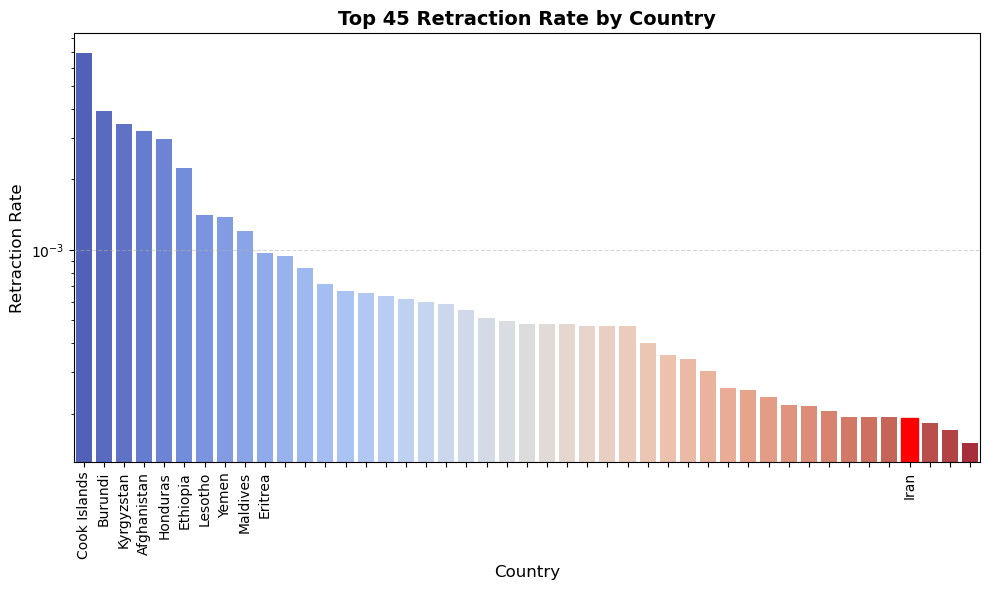

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data by retraction rate
sorted_data = merged_data.sort_values(by="Retraction_Rate", ascending=False)[:45]

# Adjust the figure size
plt.figure(figsize=(10, 6))  # Smaller figure for a 2-column layout

# Create the barplot
bars = sns.barplot(data=sorted_data, x="Country", y="Retraction_Rate", palette="coolwarm")

# Highlight Iran
for bar, country in zip(bars.patches, sorted_data["Country"]):
    if country == "Iran":
        bar.set_color("red")  # Highlight Iran in red

# Update x-axis labels to show only top 10 countries and Iran
visible_labels = list(sorted_data["Country"][:10])  # Top 10 countries
if "Iran" in sorted_data["Country"].values and "Iran" not in visible_labels:
    visible_labels.append("Iran")  # Add Iran if not already in the top 10

# Replace other x-axis labels with empty strings
x_labels = [label if label in visible_labels else "" for label in sorted_data["Country"]]
bars.set_xticklabels(x_labels, rotation=90, fontsize=10)

# Adjust axis labels and title
plt.xlabel("Country", fontsize=12)
plt.ylabel("Retraction Rate", fontsize=12)
plt.title("Top 45 Retraction Rate by Country", fontsize=14, fontweight="bold")

# Use log scale for better readability
plt.yscale("log")

# Grid for better visualization
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Optimize layout to reduce whitespace
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\Parsa\AppData\Local\Temp\ipykernel_28388\2476398841.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=sorted_data, x="Retraction_Rate", y="Country", palette="coolwarm")


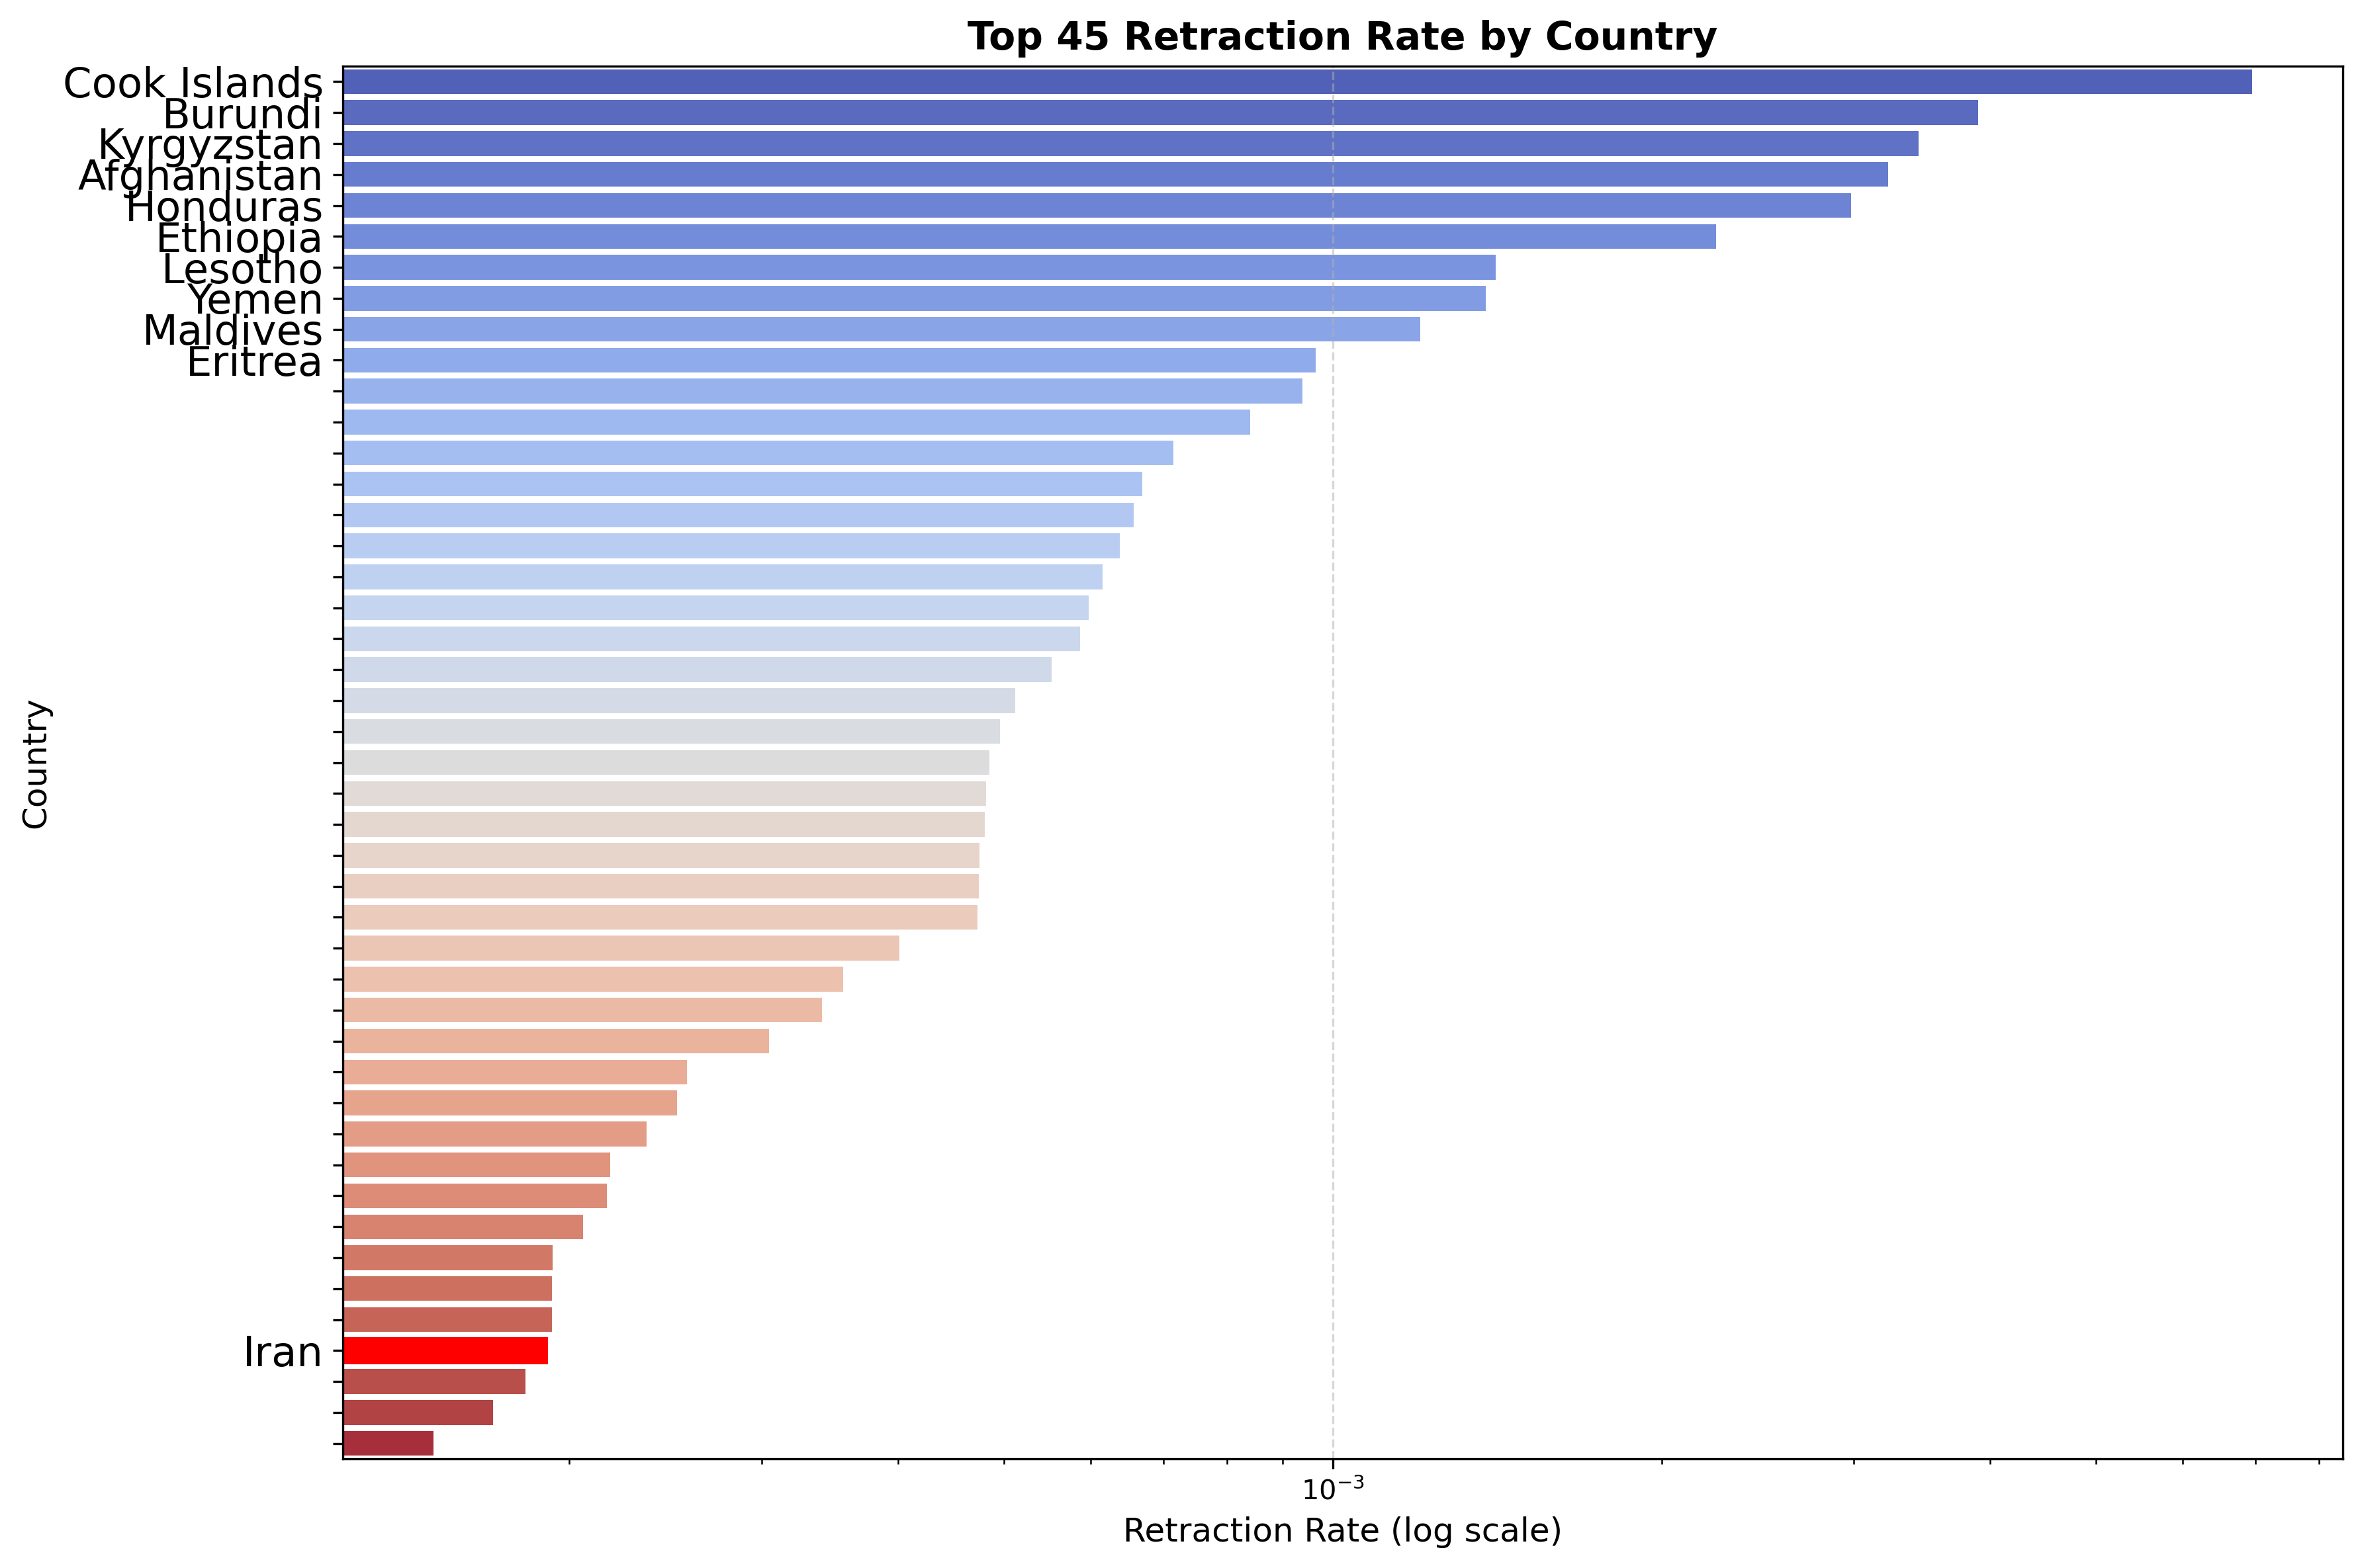

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data by retraction rate and select the top 45 entries
sorted_data = merged_data.sort_values(by="Retraction_Rate", ascending=False)[:45]

# Determine which countries to label: top 10 plus Iran
top10 = list(sorted_data["Country"][:10])
if "Iran" not in top10 and "Iran" in sorted_data["Country"].tolist():
    top10.append("Iran")

# Create a new column for custom labels: show the country only if in top10 or is Iran
sorted_data["Label"] = sorted_data["Country"].apply(lambda x: x if x in top10 else "")

# Increase figure size and dpi for publication quality
plt.figure(figsize=(12, 8), dpi=300)

# Create a horizontal bar plot with retraction rate on the x-axis and country on the y-axis
bars = sns.barplot(data=sorted_data, x="Retraction_Rate", y="Country", palette="coolwarm")

# Highlight Iran with a red bar
for patch, country in zip(bars.patches, sorted_data["Country"]):
    if country == "Iran":
        patch.set_color("red")

# Setting the x-axis to log scale
plt.xscale("log")

# Adjust axis labels, title, and grid
plt.xlabel("Retraction Rate (log scale)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.title("Top 45 Retraction Rate by Country", fontsize=14, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Customize the y-axis tick labels: only display label if it's in the top10 or is "Iran"
custom_labels = [country if country in top10 else "" for country in sorted_data["Country"]]
plt.yticks(ticks=range(len(sorted_data)), labels=custom_labels, fontsize=15)

plt.tight_layout()
plt.show()


C:\Users\Parsa\AppData\Local\Temp\ipykernel_28388\671139387.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=sorted_data, x="Retraction_Rate", y="Country", palette="coolwarm", ax=ax)


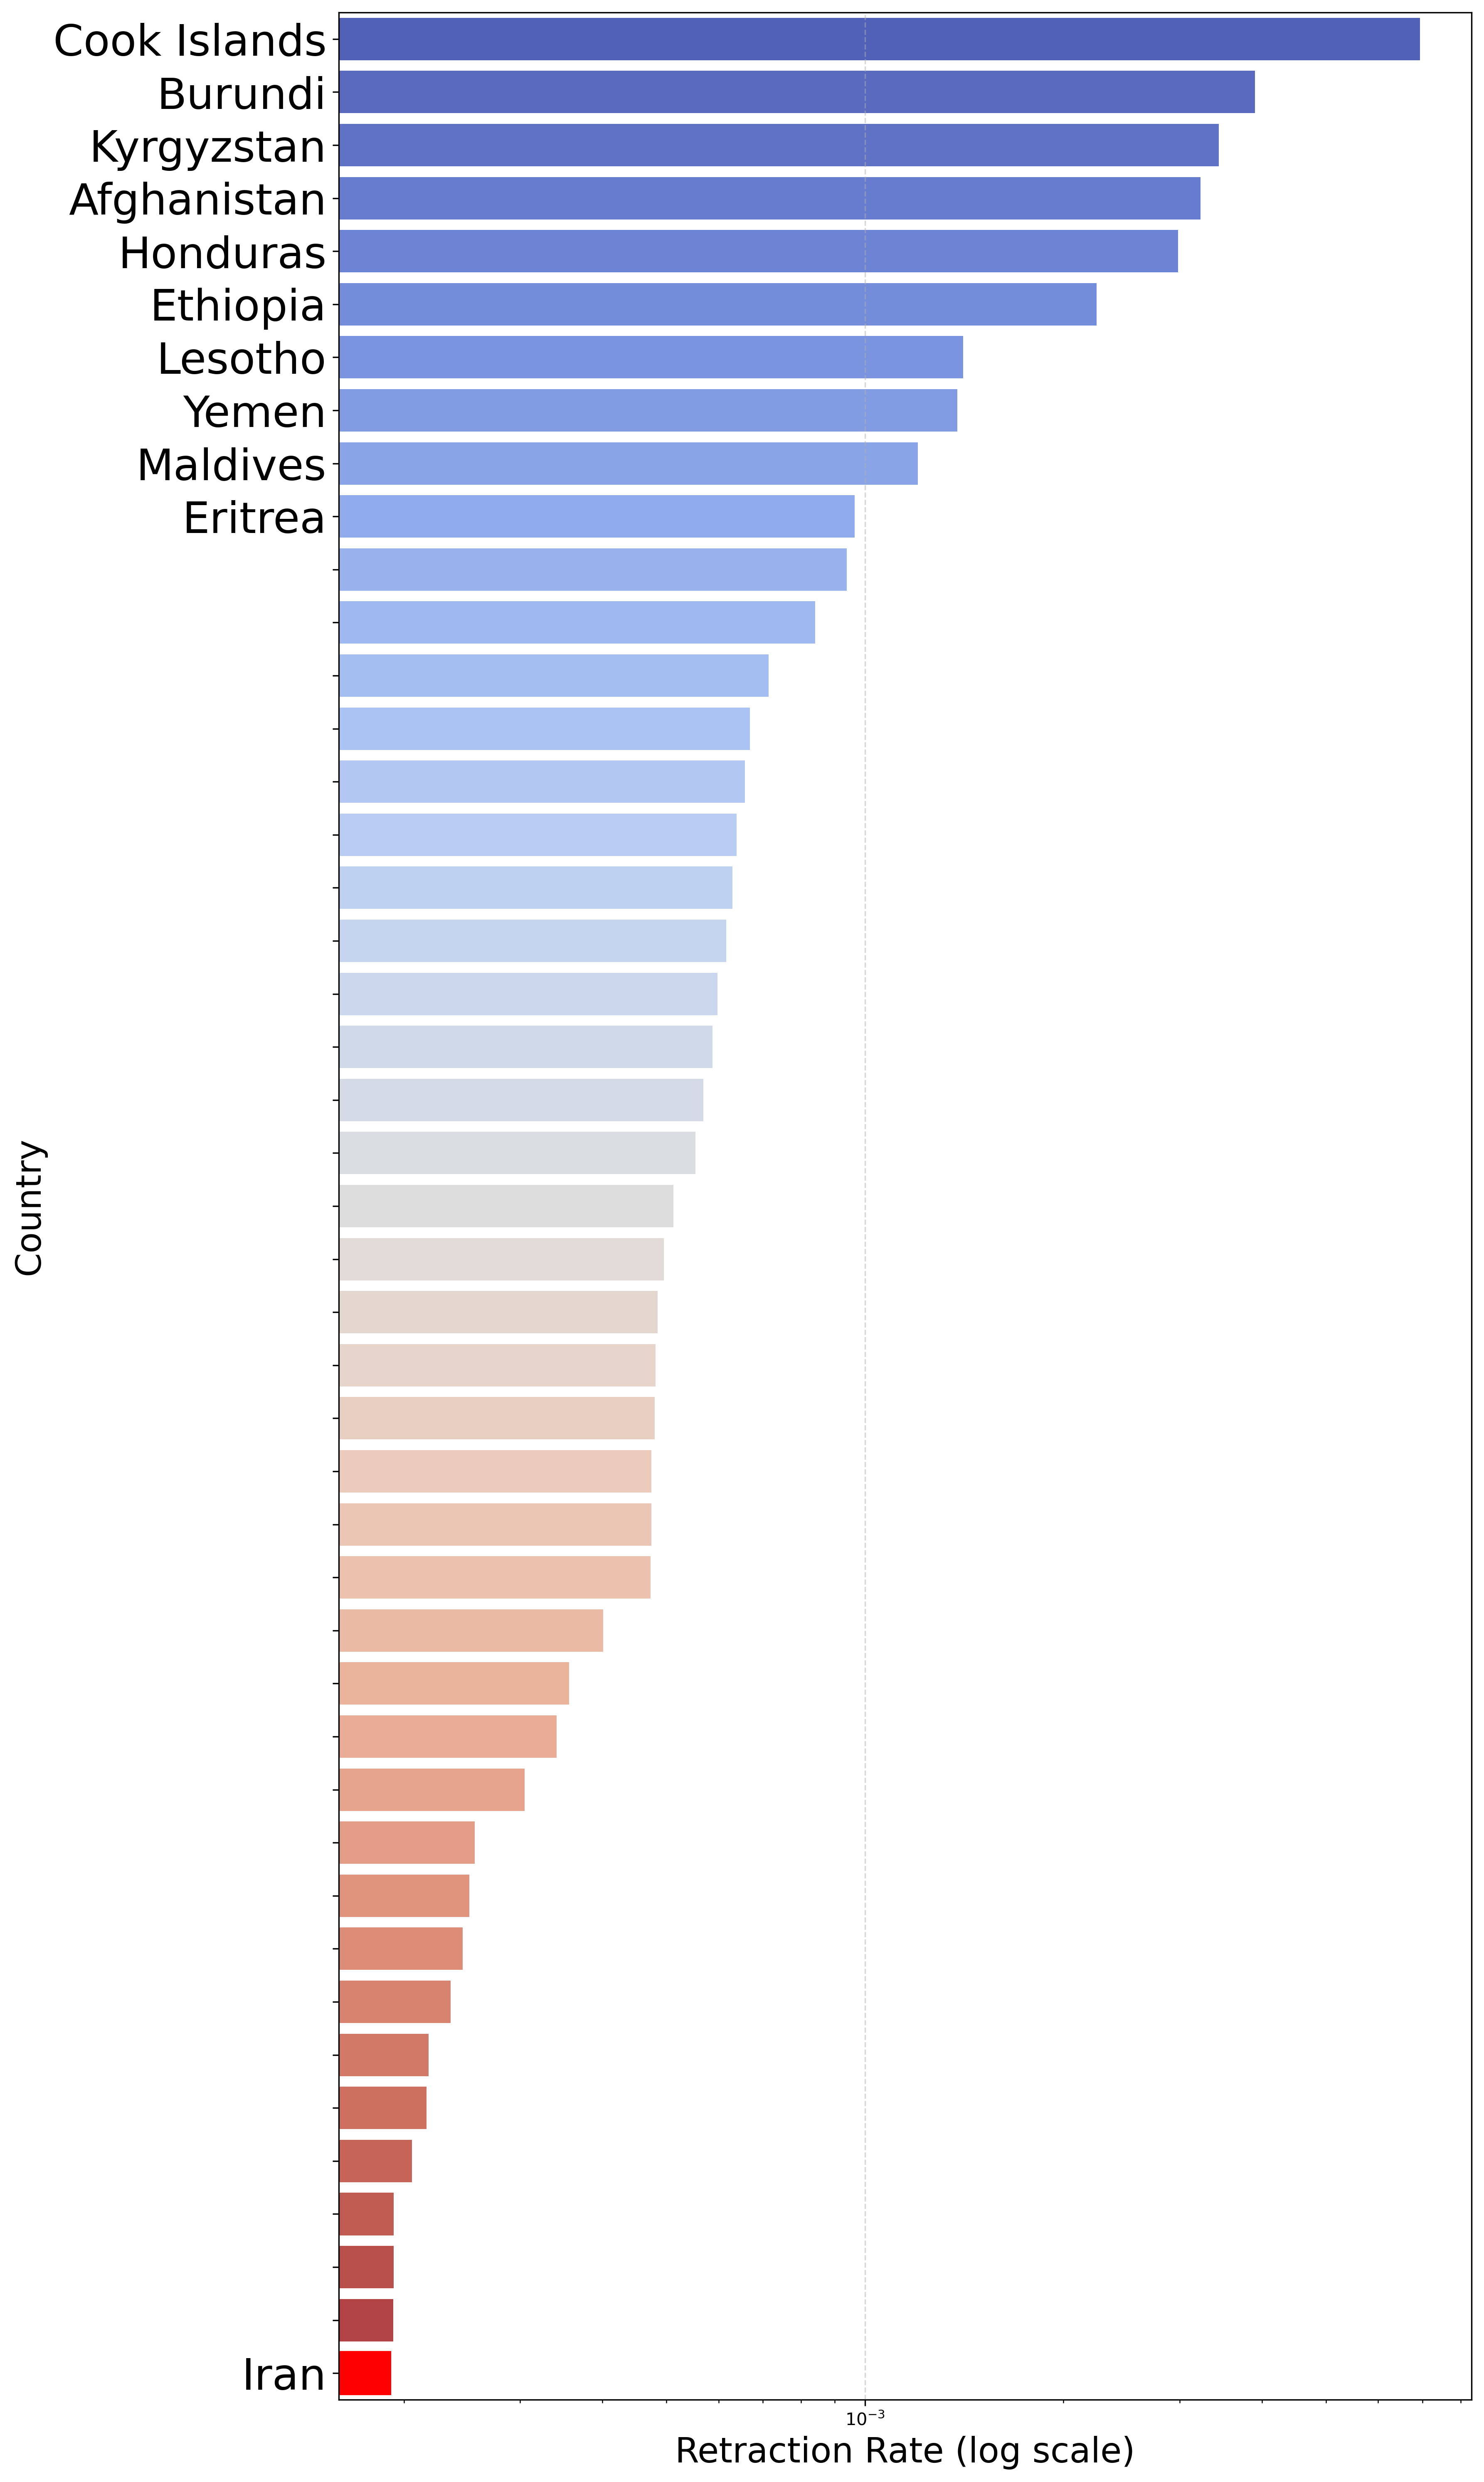

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data by retraction rate and select the top 45 entries
sorted_data = merged_data.sort_values(by="Retraction_Rate", ascending=False)[:45]

# Determine which countries to label: top 10 plus Iran
top10 = list(sorted_data["Country"][:10])
if "Iran" not in top10 and "Iran" in sorted_data["Country"].tolist():
    top10.append("Iran")

# Optionally create a custom column (if you later want to use it)
sorted_data["Label"] = sorted_data["Country"].apply(lambda x: x if x in top10 else "")

# Increase figure size (especially the height for better vertical spacing) and set a high dpi for publication quality
fig, ax = plt.subplots(figsize=(12, 20), dpi=300)

# Create a horizontal bar plot with retraction rate on the x-axis and country names on the y-axis
bars = sns.barplot(data=sorted_data, x="Retraction_Rate", y="Country", palette="coolwarm", ax=ax)

# Highlight Iran with a red bar
for patch, country in zip(bars.patches, sorted_data["Country"]):
    if country == "Iran":
        patch.set_color("red")

# Set the x-axis to log scale
ax.set_xscale("log")

# Set axis labels and title
ax.set_xlabel("Retraction Rate (log scale)", fontsize=20)
ax.set_ylabel("Country", fontsize=20)
#ax.set_title("Top 45 Retraction Rate by Country", fontsize=14, fontweight="bold")

# Draw a grid on the x-axis
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Customize y-axis tick labels: only show the label if it's in the top10 or 'Iran'
custom_labels = [country if country in top10 else "" for country in sorted_data["Country"]]
ax.set_yticks(range(len(sorted_data)))  # tick positions
ax.set_yticklabels(custom_labels, fontsize=25)  # Increase font size for country names

plt.tight_layout()
plt.show()


C:\Users\Parsa\AppData\Local\Temp\ipykernel_28388\47578848.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=sorted_data, x="Retraction_Rate", y="Country", palette="coolwarm", ax=ax)


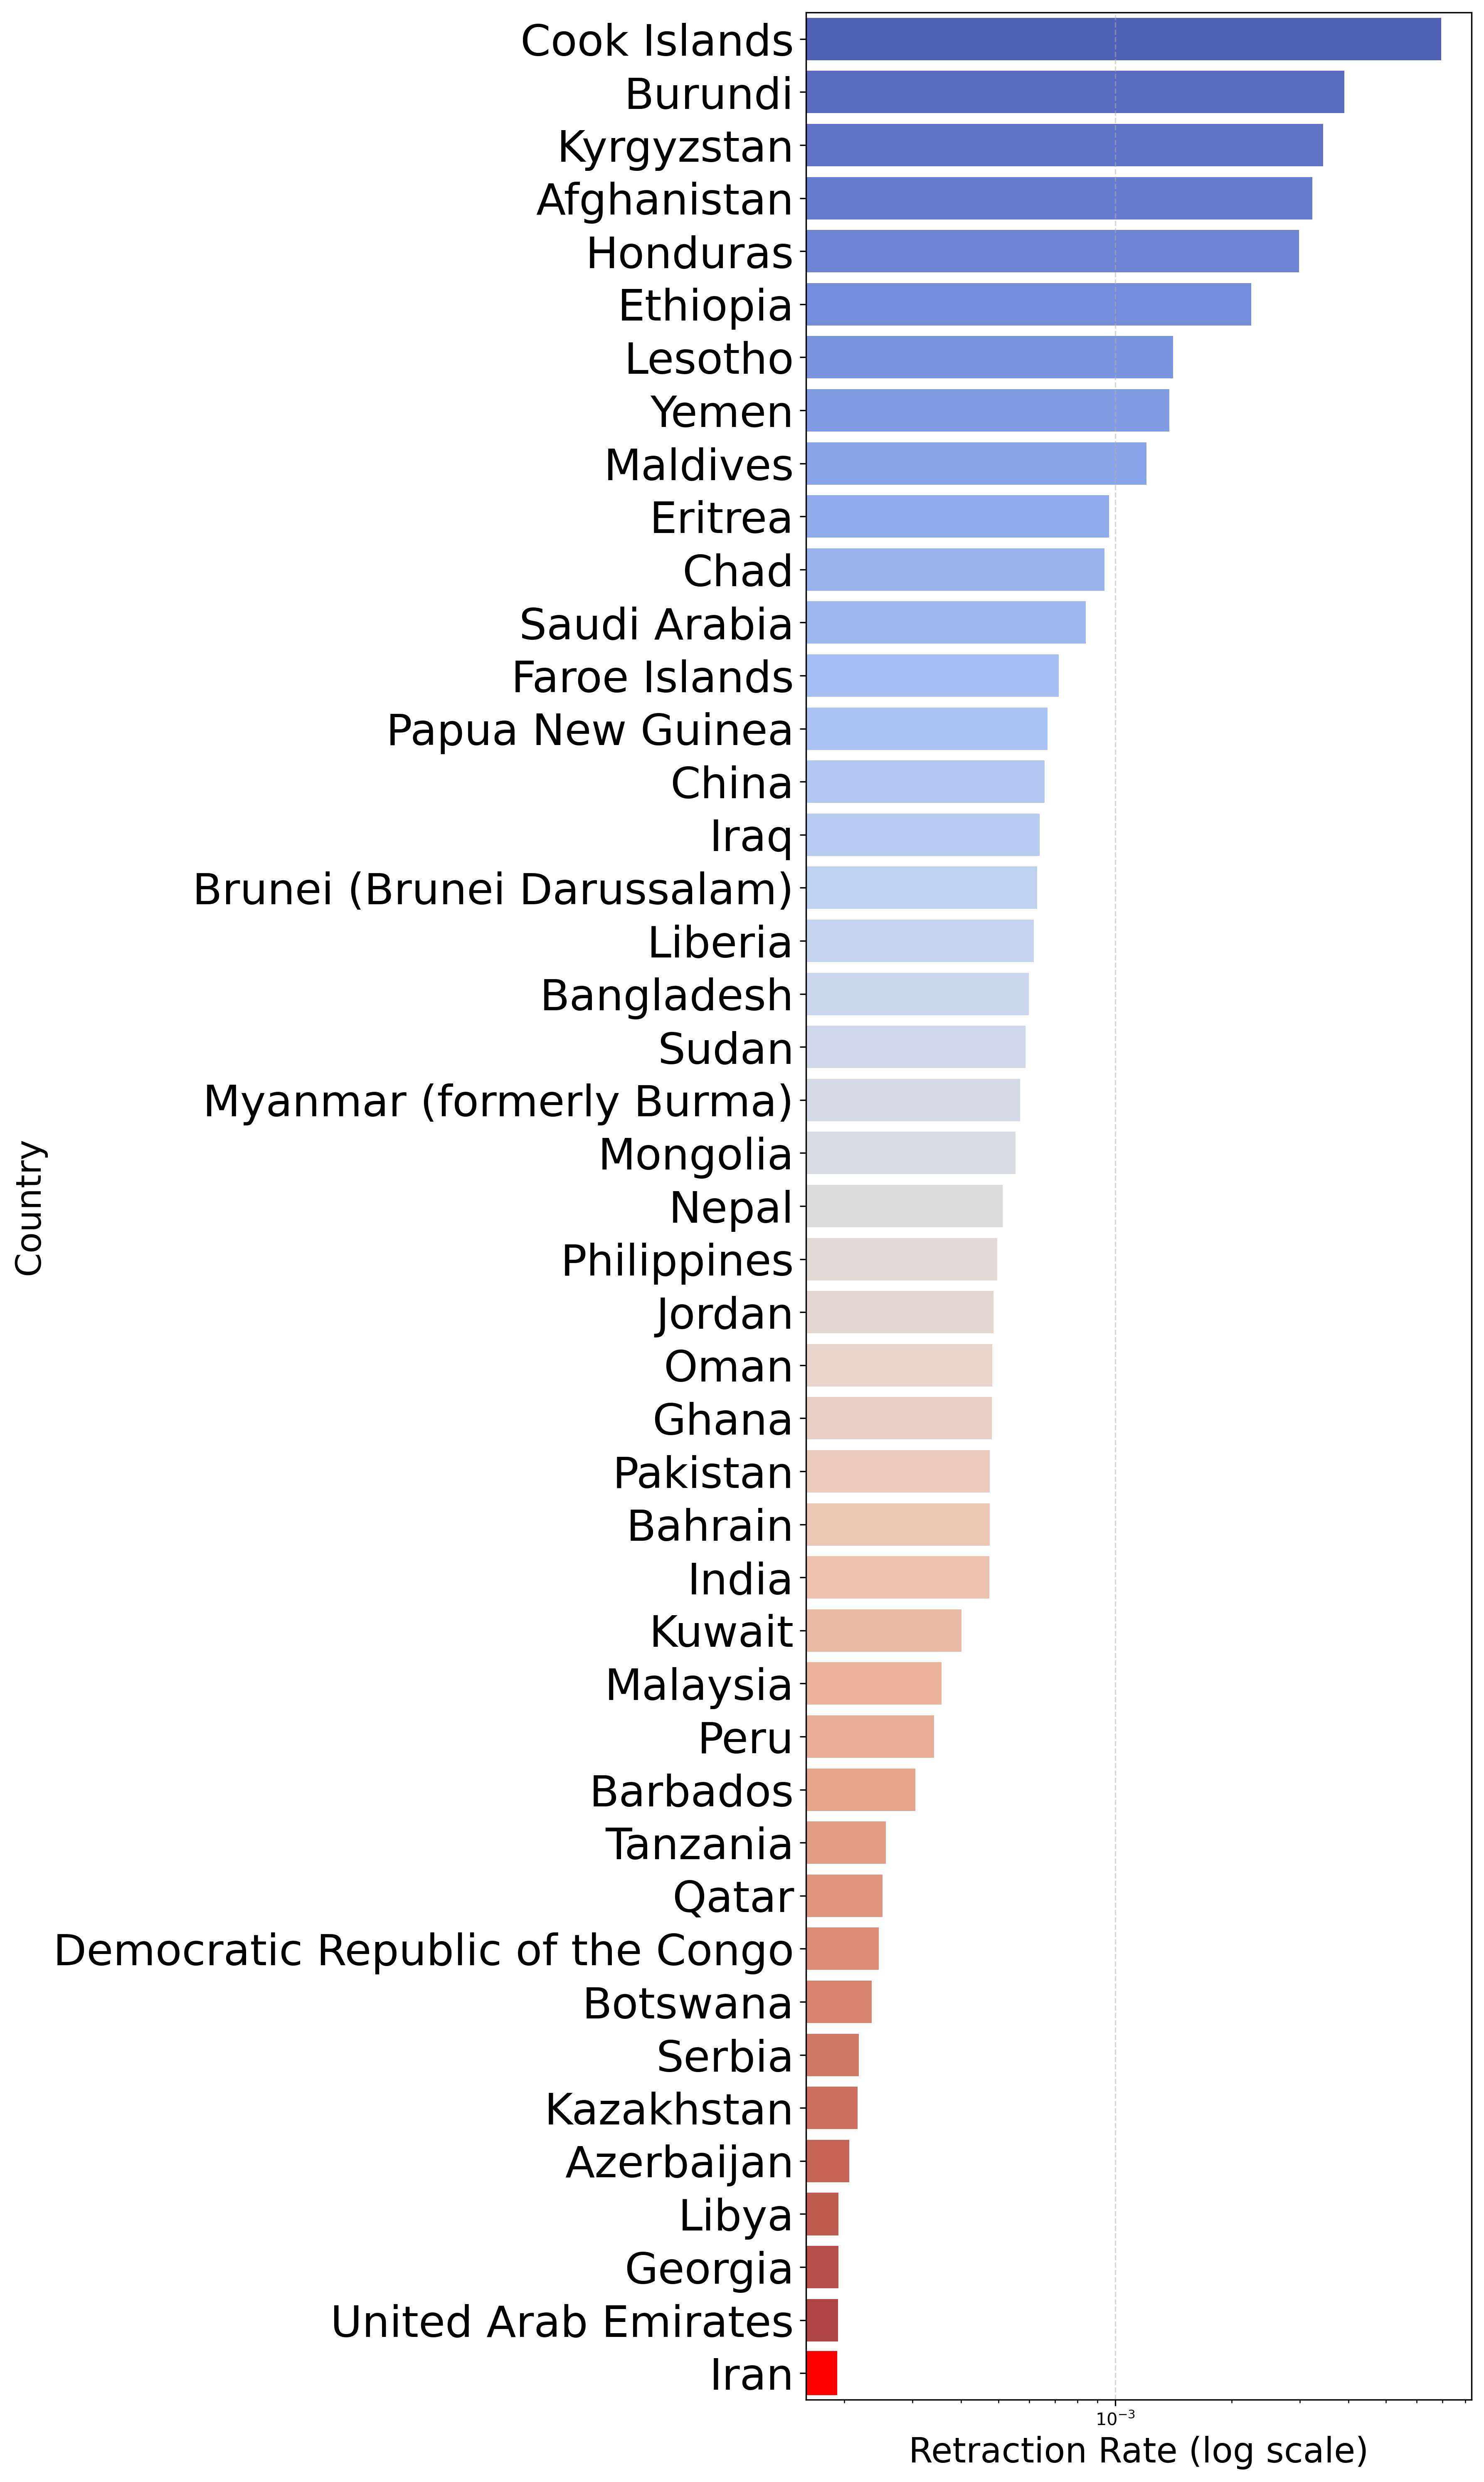

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data by retraction rate and select the top 45 entries
sorted_data = merged_data.sort_values(by="Retraction_Rate", ascending=False)[:45]

# Increase figure size (especially the height for better vertical spacing) and set a high DPI for publication quality
fig, ax = plt.subplots(figsize=(12, 20), dpi=300)

# Create a horizontal bar plot with retraction rate on the x-axis and country names on the y-axis
bars = sns.barplot(data=sorted_data, x="Retraction_Rate", y="Country", palette="coolwarm", ax=ax)

# Highlight Iran with a red bar
for patch, country in zip(bars.patches, sorted_data["Country"]):
    if country == "Iran":
        patch.set_color("red")

# Set the x-axis to log scale
ax.set_xscale("log")

# Set axis labels
ax.set_xlabel("Retraction Rate (log scale)", fontsize=20)
ax.set_ylabel("Country", fontsize=20)

# Draw a grid on the x-axis for easier interpretation
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Display all country names on the y-axis with larger font size for readability
ax.set_yticks(range(len(sorted_data)))  # set tick positions
ax.set_yticklabels(sorted_data["Country"], fontsize=25)

plt.tight_layout()
plt.show()


C:\Users\Parsa\AppData\Local\Temp\ipykernel_28388\1450783524.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=sorted_data, x="Retraction_Rate", y="Country", palette="coolwarm", ax=ax)


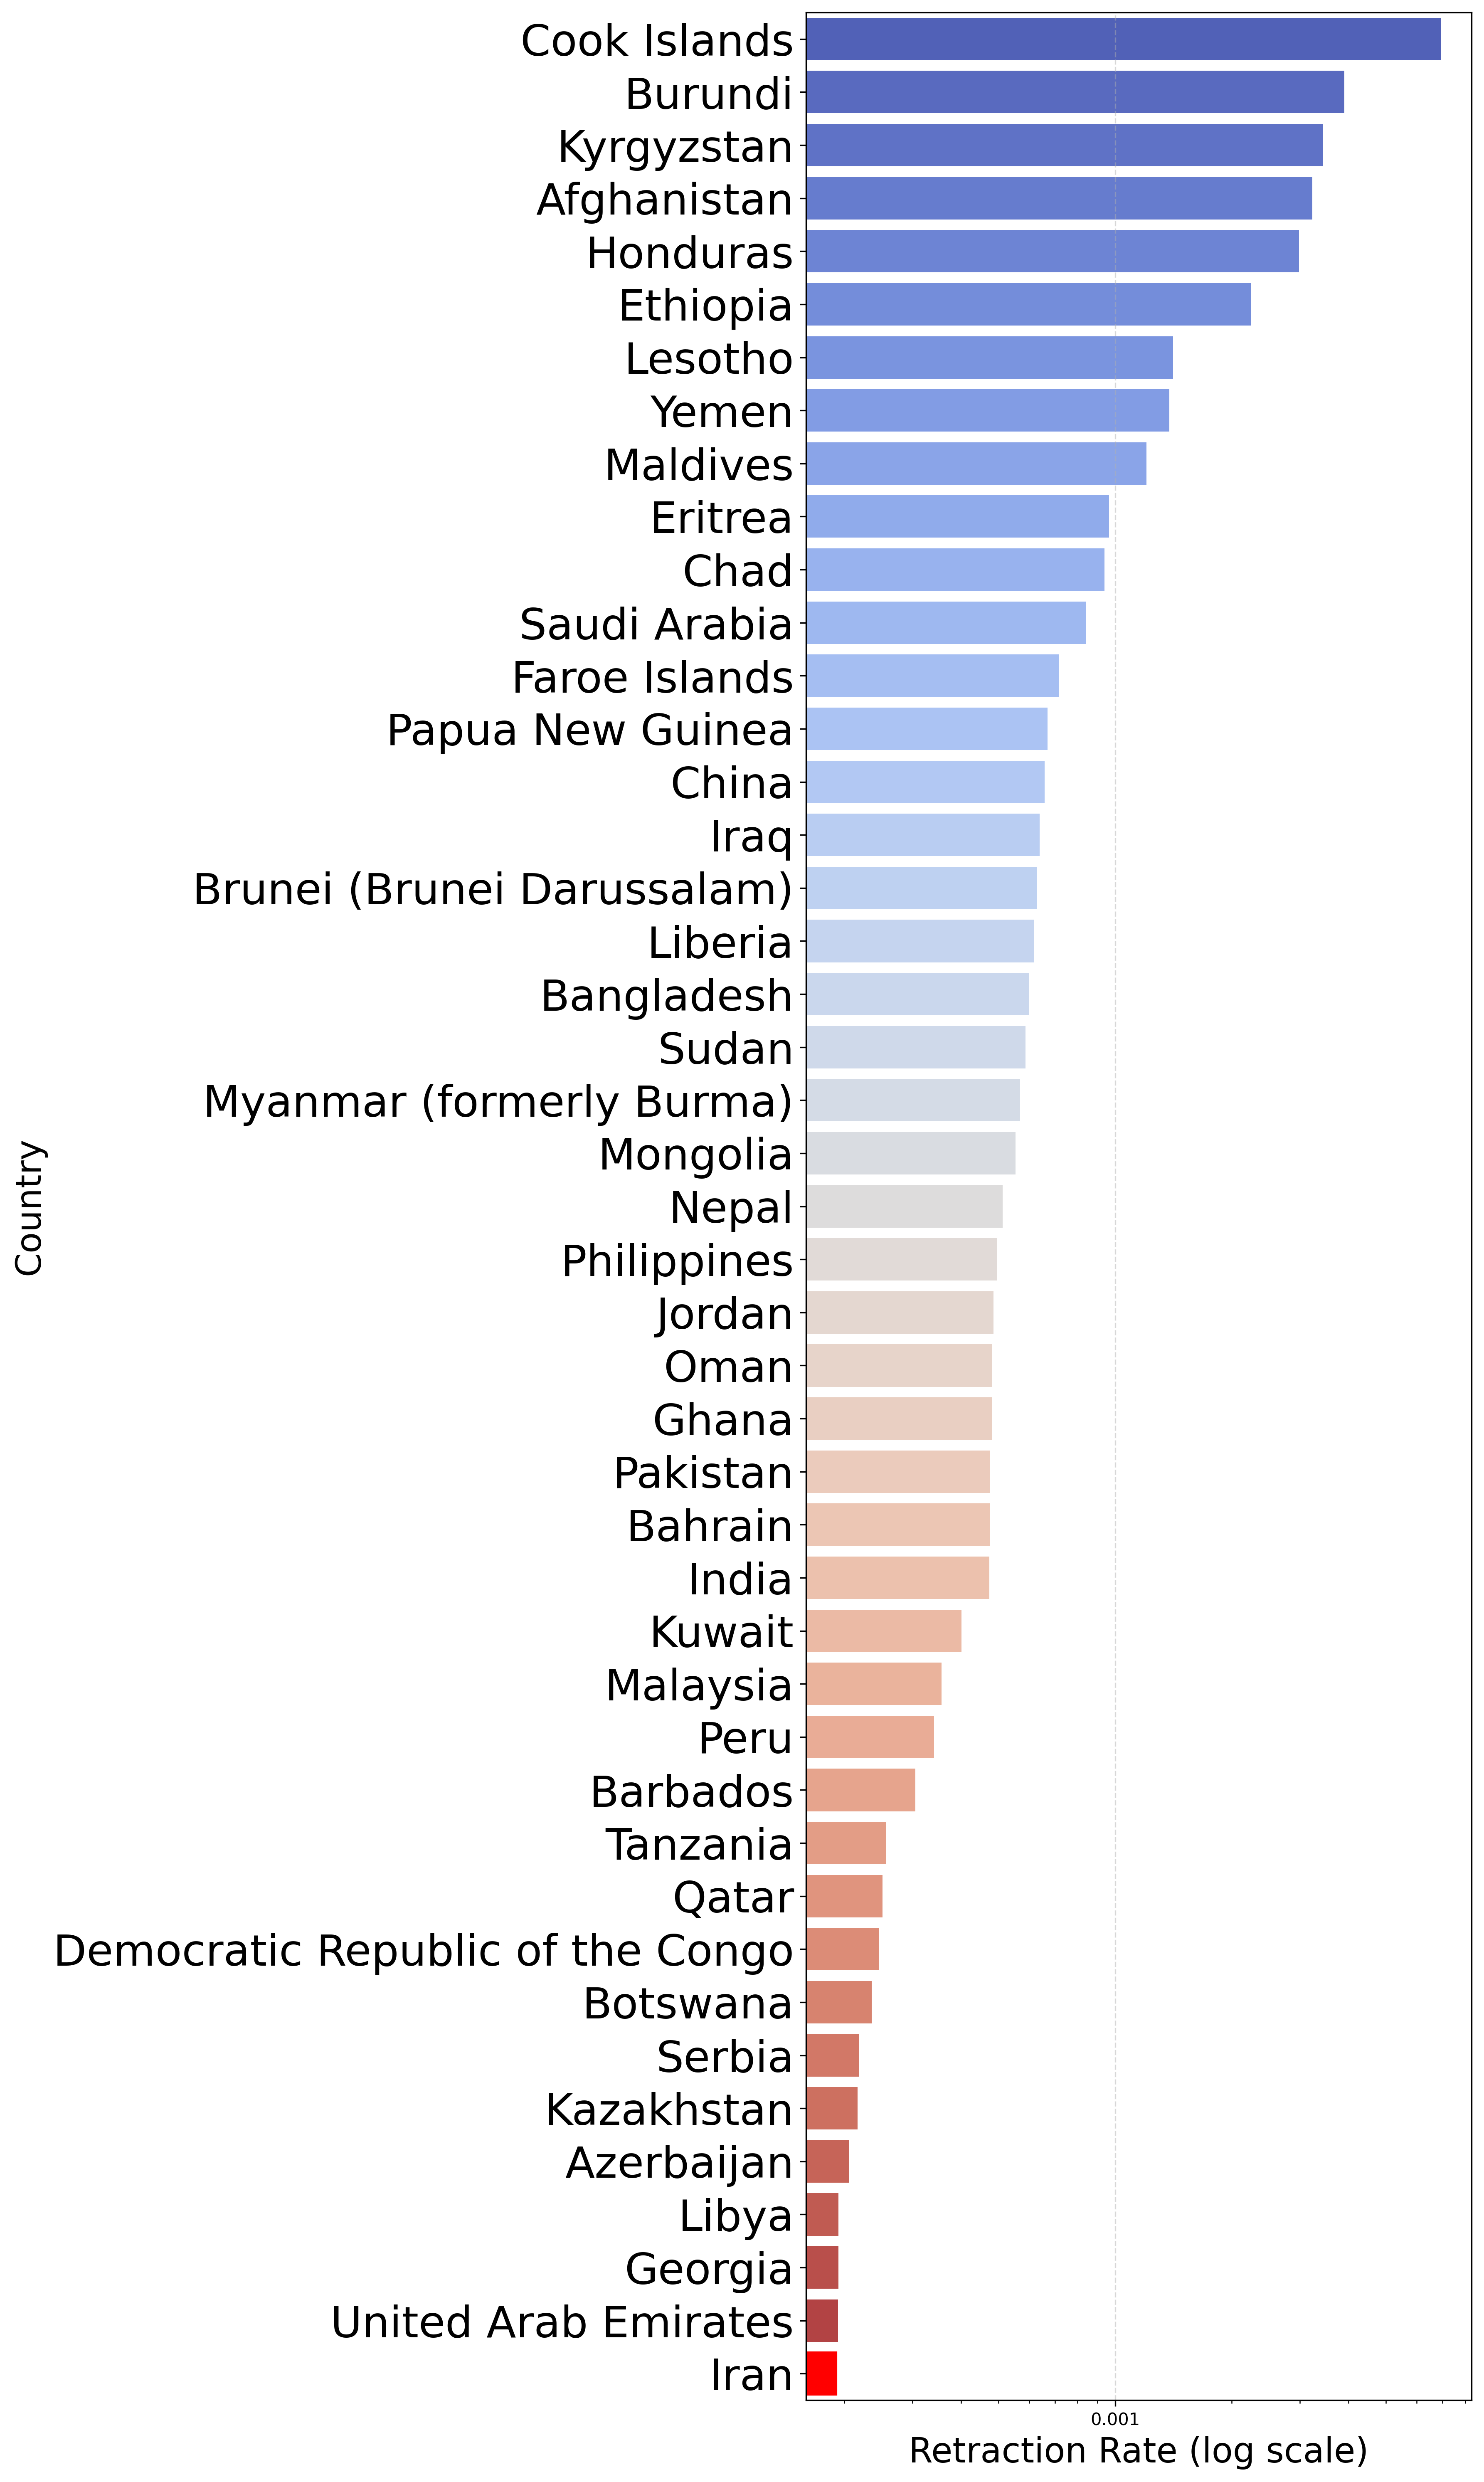

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mticker

# Sort data by retraction rate and select the top 45 entries
sorted_data = merged_data.sort_values(by="Retraction_Rate", ascending=False)[:45]

# Increase figure size (especially the height for better vertical spacing) and set a high dpi for publication quality
fig, ax = plt.subplots(figsize=(12, 20), dpi=300)

# Create a horizontal bar plot with retraction rate on the x-axis and country names on the y-axis
bars = sns.barplot(data=sorted_data, x="Retraction_Rate", y="Country", palette="coolwarm", ax=ax)

# Highlight Iran with a red bar
for patch, country in zip(bars.patches, sorted_data["Country"]):
    if country == "Iran":
        patch.set_color("red")

# Set the x-axis to log scale
ax.set_xscale("log")

# Configure the x-axis to show additional tick numbers:
# Use LogLocator to add more ticks along the logarithmic scale.
ax.xaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=20))
# Use a custom formatter to display tick labels without scientific notation if desired
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x:g}'))

# Optionally, add minor ticks for further granularity (without labels)
ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10)*0.1))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

# Set axis labels with larger font sizes for clarity
ax.set_xlabel("Retraction Rate (log scale)", fontsize=20)
ax.set_ylabel("Country", fontsize=20)

# Draw a grid on the x-axis for easier interpretation
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Display all country names on the y-axis with a larger font size
ax.set_yticks(range(len(sorted_data)))
ax.set_yticklabels(sorted_data["Country"], fontsize=25)

plt.tight_layout()
plt.show()


Text(0.5, 110.99999999999999, 'Retraction Rate (log scale)')

C:\Users\Parsa\AppData\Local\Temp\ipykernel_28388\226069028.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=sorted_data, x="Retraction_Rate", y="Country", palette="coolwarm", ax=ax)


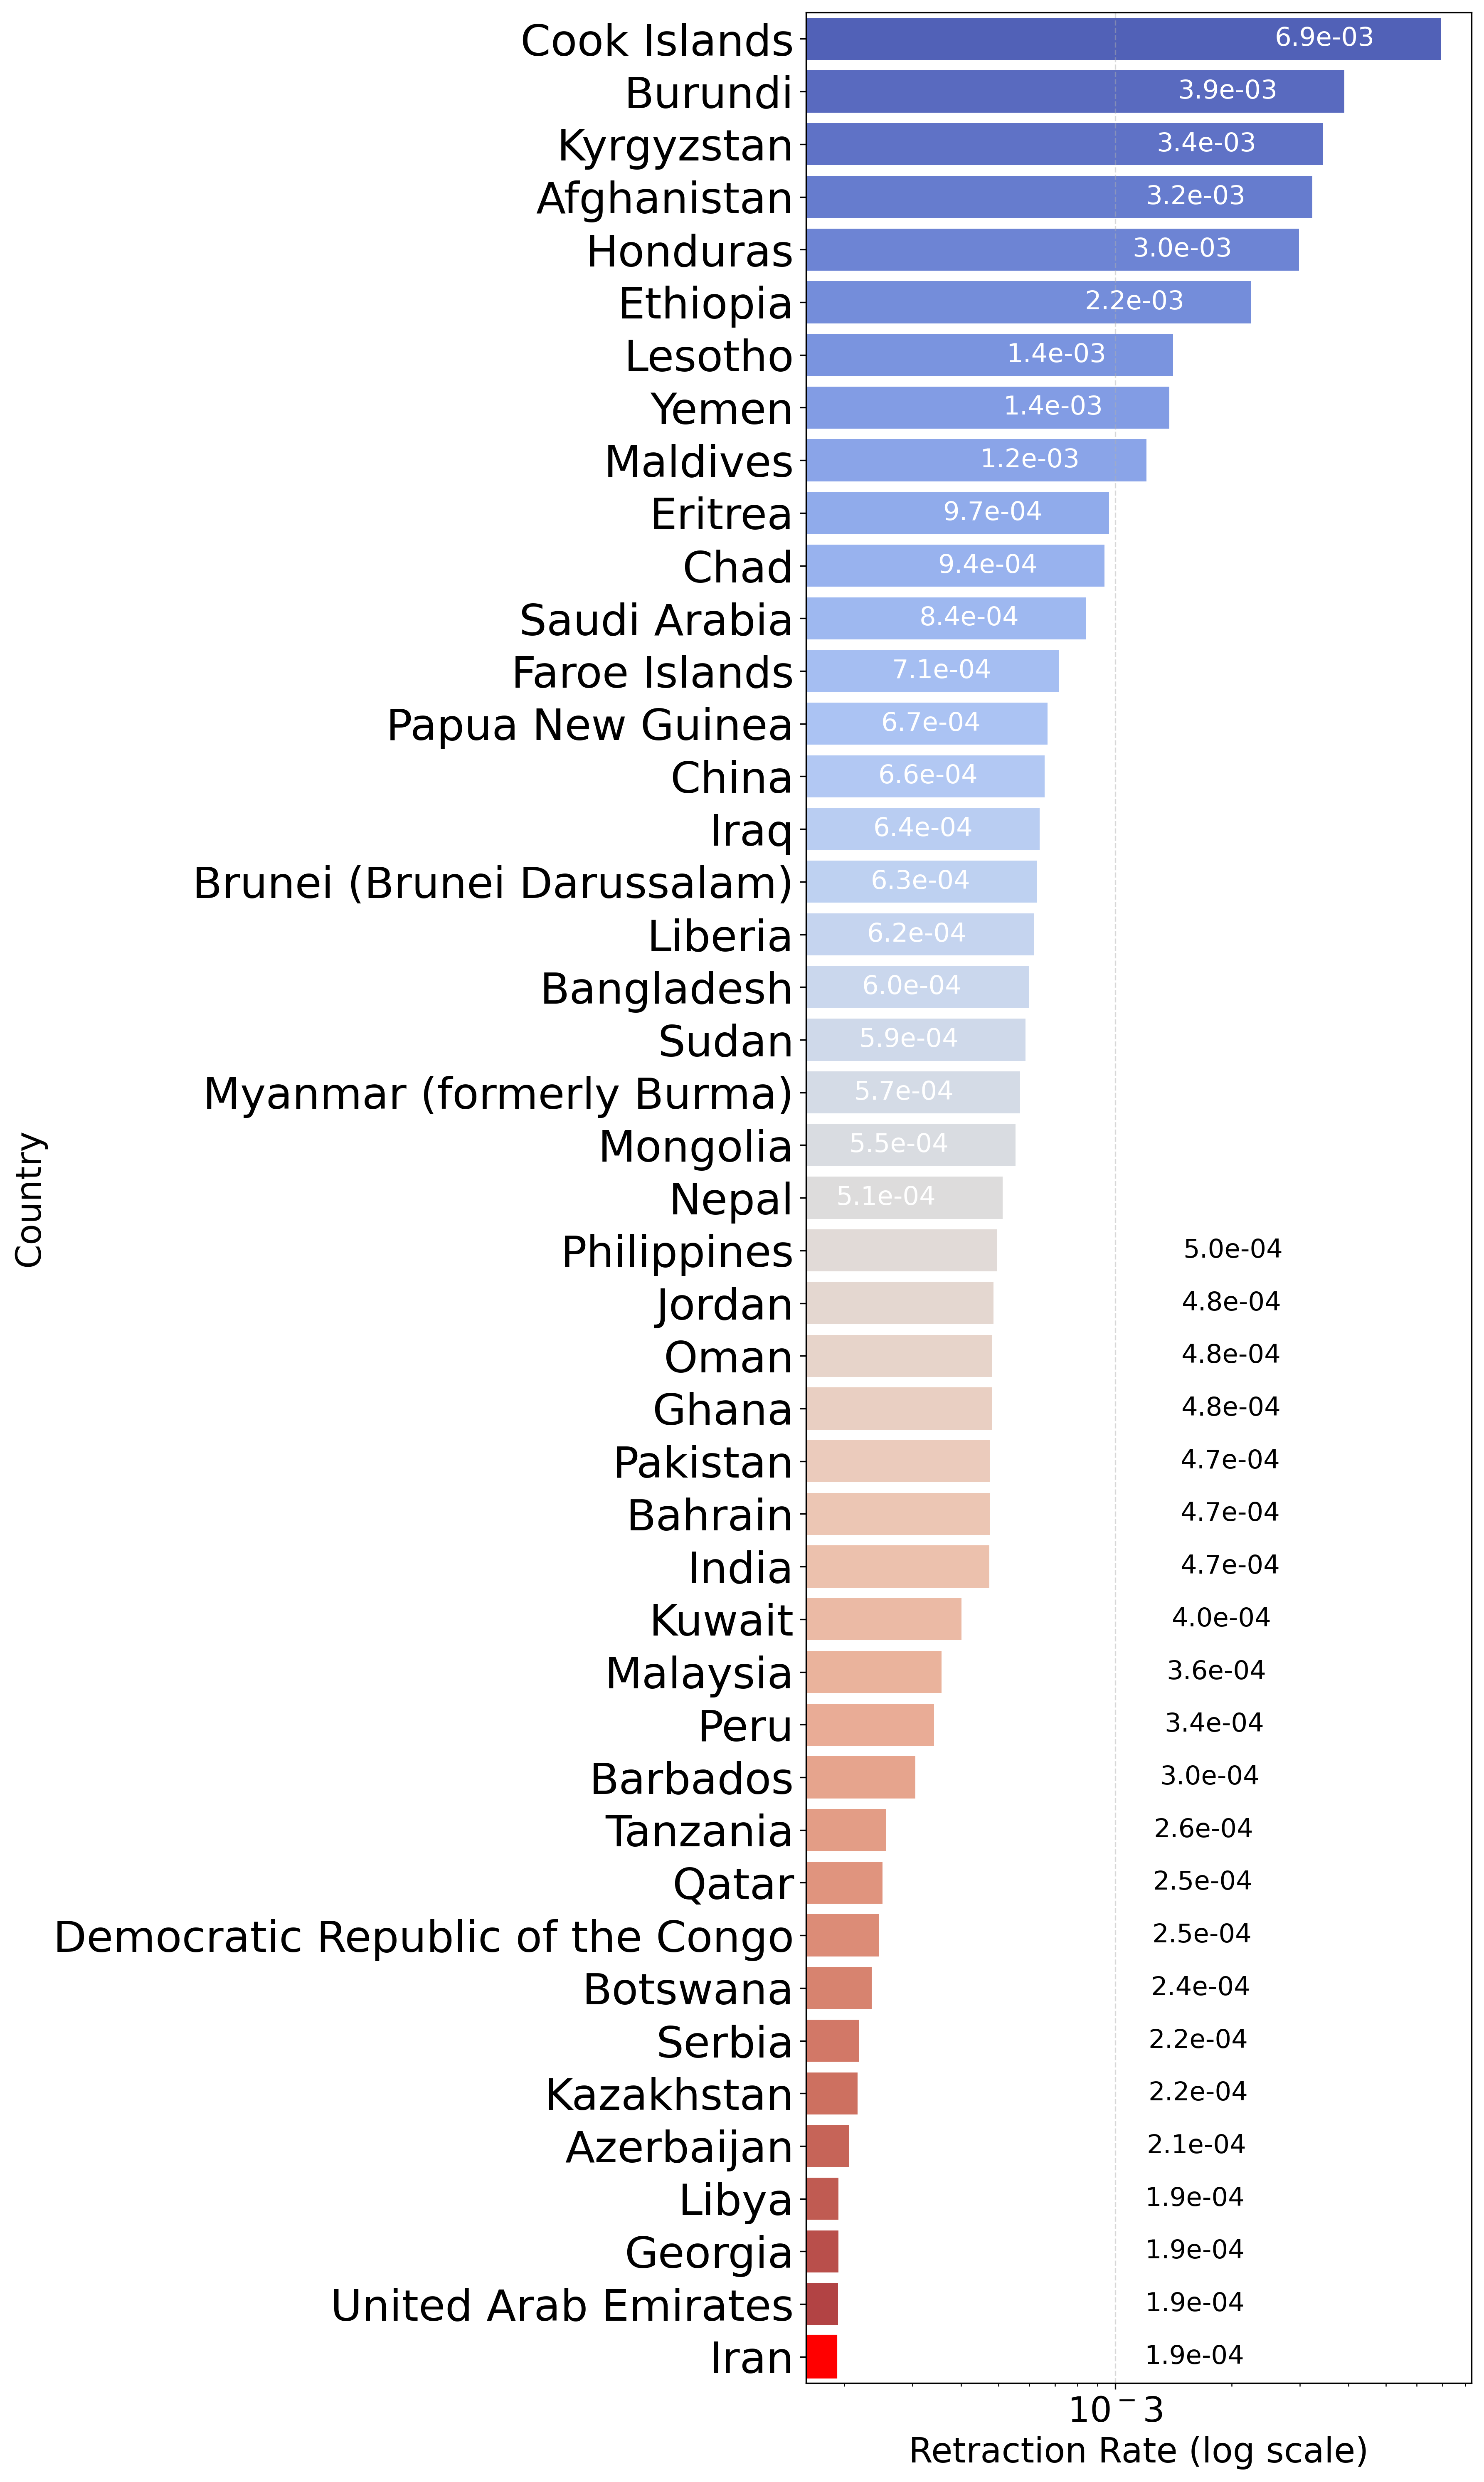

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data by retraction rate and select the top 45 entries
sorted_data = merged_data.sort_values(by="Retraction_Rate", ascending=False)[:45]

# Increase figure size (especially the height for better vertical spacing) and set a high DPI for publication quality
fig, ax = plt.subplots(figsize=(12, 20), dpi=300)

# Create a horizontal bar plot with retraction rate on the x-axis and country names on the y-axis
bars = sns.barplot(data=sorted_data, x="Retraction_Rate", y="Country", palette="coolwarm", ax=ax)

# Highlight Iran with a red bar
for patch, country in zip(bars.patches, sorted_data["Country"]):
    if country == "Iran":
        patch.set_color("red")

# Set the x-axis to log scale
ax.set_xscale("log")

# Set axis labels
ax.set_xlabel("Retraction Rate (log scale)", fontsize=20)
ax.set_ylabel("Country", fontsize=20)

# Draw a grid on the x-axis for easier interpretation
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Display all country names on the y-axis with larger font size for readability
ax.set_yticks(range(len(sorted_data)))  # set tick positions
ax.set_yticklabels(sorted_data["Country"], fontsize=25)
# Set the x-axis to log scale
ax.set_xscale("log")

# Manually set ticks and labels for log scale
log_ticks = [10**-3]  # Add 10^-3 and 10^-4
log_labels = ["$10^-3$"]
ax.set_xticks(log_ticks)
ax.set_xticklabels(log_labels, fontsize=20)

# Set axis labels
ax.set_xlabel("Retraction Rate (log scale)", fontsize=20)

# Annotate values on the bars
for bar, value in zip(bars.patches, sorted_data["Retraction_Rate"]):
    if bar.get_width() < 0.0005:  # Adjust the threshold based on your dataset
        # For small bars, position the text outside, just in front of the bar
        ax.text(
            bar.get_width() + 0.001,  # Slightly offset to the right
            bar.get_y() + bar.get_height() / 2,  # Centered vertically
            f"{value:.1e}",  # Format the value in scientific notation
            fontsize=15,
            va="center",  # Vertically align in the center
            ha="left"  # Horizontally align to the left of the text
        )
    else:
        # For larger bars, position the text inside the bar
        ax.text(
            bar.get_width() / 2,  # Center the text horizontally in the bar
            bar.get_y() + bar.get_height() / 2,  # Centered vertically
            f"{value:.1e}",  # Format the value in scientific notation
            fontsize=15,
            va="center",  # Vertically align in the center
            ha="center",  # Horizontally align in the center
            color="white"  # Use contrasting color for visibility
        )




plt.tight_layout()
plt.show()
